In [1]:
# initialize stuff
import sys
import logging
import importlib

import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt

from tqdm import tqdm
from scipy.optimize import curve_fit

# import theory stuff

HOME_DIR = "/Users/oliver/Documents/p5control-bluefors-evaluation"
sys.path.append(HOME_DIR)

import superconductivity.api as sc

from superconductivity.style.cpd4 import cmap, colors

import numpy as np

from matplotlib.markers import MarkerStyle
from matplotlib.lines import Line2D

import superconductivity.api as sc

from superconductivity.api import G_0_muS
from superconductivity.api import NDArray64

from IPython import get_ipython

_ip = get_ipython()
if _ip is not None:
    _ip.run_line_magic("matplotlib", "inline")
    _ip.run_line_magic("reload_ext", "autoreload")
    _ip.run_line_magic("autoreload", "2")

    _ip.run_line_magic(
        "config",
        "InlineBackend.print_figure_kwargs = {'bbox_inches': None, 'pad_inches': 0.0}",
    )
    _ip.run_line_magic("config", 'InlineBackend.figure_format = "retina"')  # or "png"
    _ip.run_line_magic(
        "config", "InlineBackend.rc = {'figure.dpi': 300}"
    )  # choose a value you like

(base) ... BaseClass initialized.
(base eva) ... BaseEvaluation initialized.
(iv eva) ... IVEvaluation initialized.
(base) ... BaseClass initialized.
(base plot) ... BasePlot initialized.
(iv plot) ... IVPlot initialized.
(base) Amplitude Study (15GHz, Antenna)
(base) loadData()
(base plot) saveFigure()
(base plot) saveFigure()


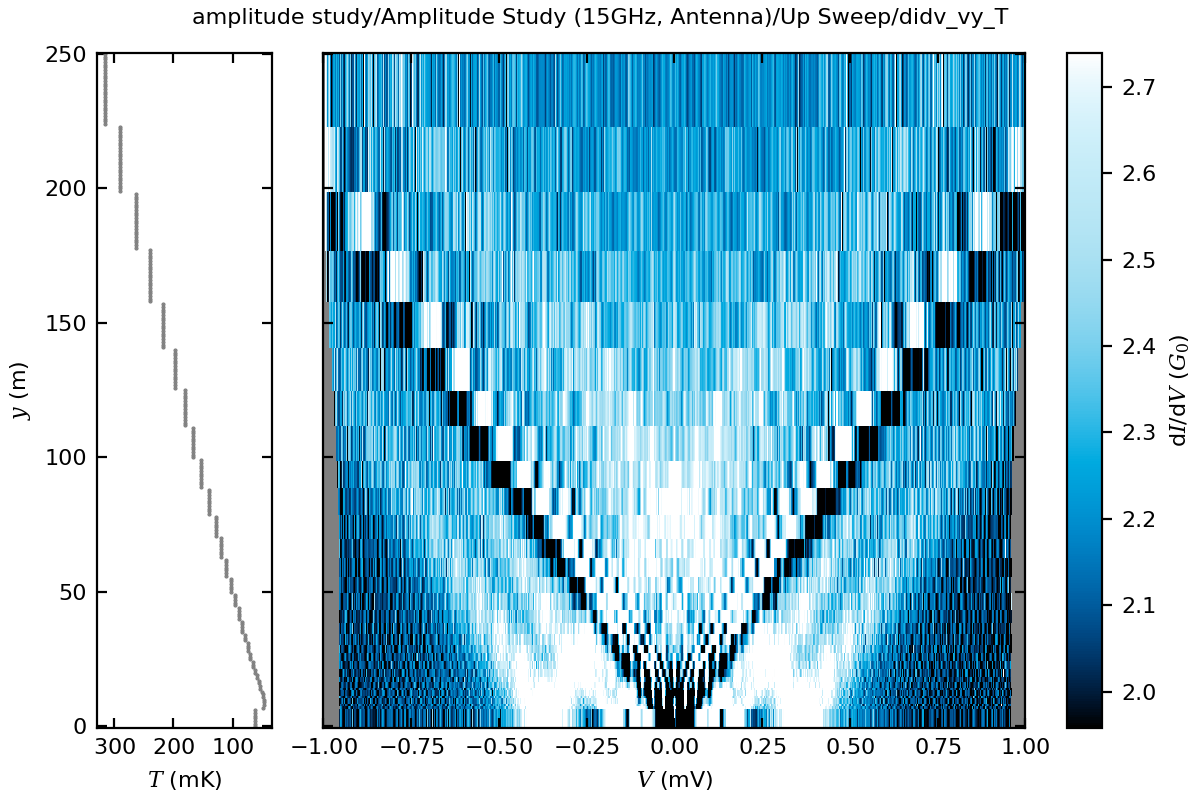

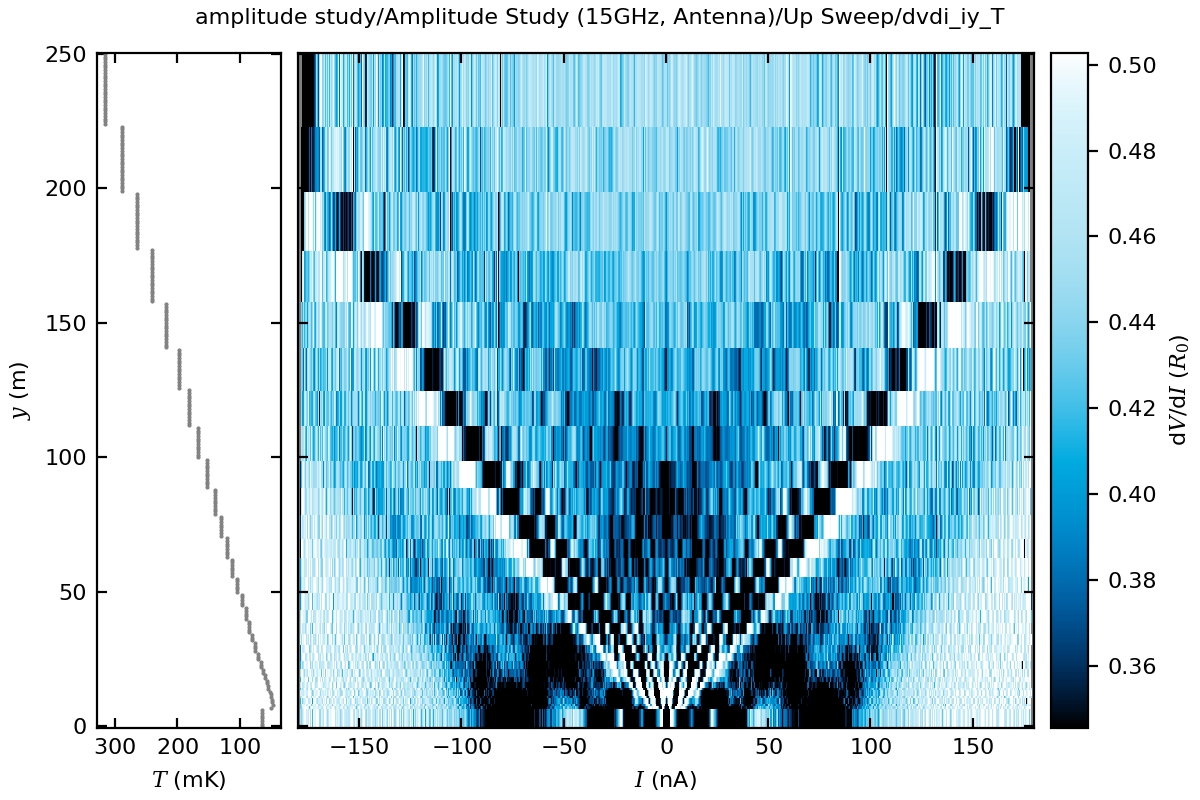

In [2]:
from utilities.ivplot import IVPlot

importlib.reload(sys.modules["utilities.ivevaluation"])
eva = IVPlot()
eva.sub_folder = ""
eva.title = "Amplitude Study (15GHz, Antenna)"
eva.loadData()
eva.to_plot = eva.up_sweep
eva.plot_all()

In [3]:
V_mV = eva.mapped["voltage_axis"] * 1e3
A_out_mV = eva.mapped["amplitude_axis"] * 1e3

I_exp_nA = eva.up_sweep["current"] * 1e9
T_exp_K = eva.up_sweep["temperature"]
dIdV_exp = eva.up_sweep["differential_conductance"]

I0exp_nA = I_exp_nA[0, :]

In [37]:
tau = np.array([0.78, 0.66, 0.31, 0.16, 0.08, 0.03])
G_N = np.sum(tau)

Isw = 0.05
T_K = 0.5
Delta_meV = 0.1885
gamma_meV = 0
A_mV = 0.0
C_pF = 0.0  # 1.08e-3
nu_GHz = 10.0

from superconductivity.models.ha_sym import get_I_ha_sym_nA as get_I_ha_nA
from superconductivity.models.abs import get_Ic_abs_nA

Iqp_nA = np.zeros_like(V_mV)
Ic_nA = 0.0
for i_tau, tau_i in enumerate(tqdm(tau)):
    Iqp_nA += get_I_ha_nA(
        V_mV=V_mV, tau=tau_i, T_K=T_K, Delta_meV=Delta_meV, gamma_meV=gamma_meV
    )
    Ic_nA += get_Ic_abs_nA(Delta_meV=Delta_meV, tau=tau_i, T_K=T_K)

Isw_nA = Isw * Ic_nA

100%|██████████| 6/6 [00:00<00:00, 829.41it/s]


In [ ]:
from superconductivity.models.rcsj import get_I_rcsj_nA

I_rcsj_nA = get_I_rcsj_nA(
    V_mV=V_mV,
    I_qp_nA=Iqp_nA,
    I_sw_nA=Isw_nA,
    T_K=T_K,
    C_pF=C_pF,
    A_mV=A_mV,
    nu_GHz=nu_GHz,
    G_min_muS=1.0,
)

In [39]:
_ip.run_line_magic("matplotlib", "qt")

GN_muS = G_N * sc.G_0_muS
dG0exp_GN = np.gradient(I0exp_nA, V_mV) / (GN_muS)
dGqp_GN = np.gradient(Iqp_nA, V_mV) / (GN_muS)
dGrcsj_GN = np.gradient(I_rcsj_nA, V_mV) / (GN_muS)

fig, [axI, axG] = plt.subplots(nrows=2, sharex=True)

axI.plot(V_mV, I0exp_nA, "k.", label="$I_{exp}$")
axI.plot(V_mV, Iqp_nA, label="$I_{qp}$")
axI.vlines(0, ymin=-Isw_nA, ymax=Isw_nA, label="$I_{sw}$")
axI.plot(V_mV, I_rcsj_nA, "r.-", label="$I_{rcsj}$")
axI.legend()

axG.plot(V_mV, dG0exp_GN, "k.", label="$dG_{exp}$")
axG.plot(V_mV, dGqp_GN, label="$dG_{qp}$")
axG.plot(V_mV, dGrcsj_GN, "r.-", label="$dG_{rcsj}$")
axG.legend()